# 02 — Etiquetas del maestro

Simulador = bucle online del repo (`ExtremePointOnlineSession` + `ValidatorMask` + `encode_option`).

En cada paso se guardan los 35 features de **todas** las candidatas legales y el índice que elige el maestro.

Maestro: `receding_horizon_ep` (el único informativo). `privileged_volume_ep` está prohibido: su etiqueta es una función cerrada de 6 features. `collect_dataset` rechaza un maestro tautológico.

Los 5 de `examples/` **no se colectan**. Este notebook no entrena.

In [1]:
from pathlib import Path
import sys

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

HERE = Path.cwd().resolve()
if HERE.name == "notebooks":
    ML_ROOT = HERE.parent
else:
    ML_ROOT = HERE if (HERE / "src_ml").is_dir() else Path("/home/edmundo/packing-services/online_policy_ml")

REPO_ROOT = ML_ROOT.parent
for p in (ML_ROOT / "src_ml", REPO_ROOT / "src"):
    s = str(p)
    if s not in sys.path:
        sys.path.insert(0, s)

from bootstrap import setup
setup()

import json
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

print("ML_ROOT =", ML_ROOT)

ML_ROOT = /home/edmundo/packing-services/online_policy_ml


In [2]:
from config import REGIMES, SEED, TEACHER_NAME
from paths import (
    BED_JSON_NAME,
    HOLDOUT_DIR,
    ORDER_IDS_NAME,
    REPORTS_DIR,
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    transitions_path,
)
from splits import load_orders
from collect import collect_dataset, collect_order_transitions, load_transitions, save_transitions
from problems import order_to_problem
from packing_services.online.features import FEATURE_DIM, FEATURE_NAMES, FEATURE_VERSION

split_dirs = {"train": TRAIN_DIR, "val": VAL_DIR, "test": TEST_DIR}
for name, path in split_dirs.items():
    assert (path / BED_JSON_NAME).is_file(), f"Falta fase 1: {path / BED_JSON_NAME}"

datasets = {name: load_orders(path / BED_JSON_NAME) for name, path in split_dirs.items()}
ids = {name: json.loads((path / ORDER_IDS_NAME).read_text(encoding="utf-8")) for name, path in split_dirs.items()}
holdout_ids = json.loads((HOLDOUT_DIR / ORDER_IDS_NAME).read_text(encoding="utf-8"))
for name, oids in ids.items():
    leak = set(oids) & set(holdout_ids)
    assert not leak, f"{name} contiene demo: {leak}"

print("FEATURE_VERSION", FEATURE_VERSION, "FEATURE_DIM", FEATURE_DIM)
print("maestro:", TEACHER_NAME, "semilla:", SEED)
print("pedidos:", {k: len(v) for k, v in ids.items()})
print("regímenes:", REGIMES)

FEATURE_VERSION 1 FEATURE_DIM 35
maestro: receding_horizon_ep semilla: 42
pedidos: {'train': 24, 'val': 8, 'test': 8}
regímenes: ((1, 1), (3, 2))


## Un paso visible (train, p=1 s=1)

In [3]:
from packing_services.algorithms._constructive import order_items
from packing_services.domain.enums import SortStrategy
from packing_services.online.budget import InformationBudget
from packing_services.online.features import encode_option
from packing_services.online.mask import ValidatorMask
from packing_services.online.params import support_threshold
from packing_services.online.session import ExtremePointOnlineSession
from packing_services.online.types import StepOption
from teacher import label_index

oid = ids["train"][0]
orders = datasets["train"]
problem = order_to_problem(orders, oid, lookahead_p=1, select_s=1)
constraints = problem.constraints
session = ExtremePointOnlineSession(problem.containers, selection="best_fit")
mask = ValidatorMask(problem, min_support_ratio=support_threshold({}, constraints.basic_stability))
remaining = order_items(list(problem.items), SortStrategy.INPUT_ORDER)
select_s, observe_p = InformationBudget(observe_p=1, select_s=1).window(len(remaining))
selectable = remaining[:select_s]
preview = remaining[:observe_p]
options = []
for bi, item in enumerate(selectable):
    for cand in session.candidates(item, constraints):
        if mask.allows(cand, item, session, constraints):
            options.append(StepOption(item=item, candidate=cand, buffer_index=bi))
y = label_index(
    options,
    remaining=remaining,
    session=session,
    constraints=constraints,
    mask=mask,
)
row = encode_option(options[y], session=session, preview=preview, remaining_count=len(remaining))
print("order_id", oid, "n_items", len(problem.items))
print("opciones legales paso 0:", len(options), "| etiqueta:", y)
print("ítem:", options[y].item.id, "vol", round(options[y].item.volume), "rank_key", options[y].candidate.rank_key[:2])
print("vector dim", len(row), "(debe ser 35)")
assert len(row) == FEATURE_DIM == 35
assert 0 <= y < len(options)

order_id 00100463 n_items 48
opciones legales paso 0: 6 | etiqueta: 0
ítem: 00109511#1 vol 14720000 rank_key (-183600.0, 0.0)
vector dim 35 (debe ser 35)


## Colecta train / val / test (p=1 s=1 y p=3 s=2)

In [4]:
reports = []
for lookahead_p, select_s in REGIMES:
    print(f"\n=== p={lookahead_p} s={select_s} ===")
    for split_name in ("train", "val", "test"):
        payload = collect_dataset(
            datasets[split_name],
            ids[split_name],
            lookahead_p=lookahead_p,
            select_s=select_s,
            teacher=TEACHER_NAME,
        )
        path = transitions_path(split_name, lookahead_p, select_s)
        save_transitions(payload, path)
        n_opt = [t["n_options"] for t in payload["transitions"]]
        packed = [s["n_packed"] for s in payload["per_order"]]
        row = {
            "split": split_name,
            "p": lookahead_p,
            "s": select_s,
            "n_orders": len(ids[split_name]),
            "n_transitions": payload["n_transitions"],
            "label_rate": payload["label_rate"],
            "n_options_mean": round(sum(n_opt) / max(len(n_opt), 1), 2),
            "packed_mean": round(sum(packed) / max(len(packed), 1), 2),
            "seconds": round(payload["seconds"], 2),
        }
        reports.append(row)
        print(f"  {split_name}: {row['n_transitions']} transiciones, label_rate={row['label_rate']:.2f}, {row['seconds']}s → {path.name}")

df = pd.DataFrame(reports)
display(df)
assert df["label_rate"].min() == 1.0
assert df["n_transitions"].min() > 0
print("\nOK — transiciones escritas")


=== p=1 s=1 ===
    1/24 00100463 tr=45 packed=45 25.44s
    10/24 00102884 tr=37 packed=37 10.86s
    20/24 00107701 tr=49 packed=49 29.68s
    24/24 00109288 tr=45 packed=45 13.19s
  train: 1006 transiciones, label_rate=1.00, 715.72s → transitions_p1s1.pkl
    1/8 00101450 tr=28 packed=28 2.35s
    8/8 00109074 tr=59 packed=59 52.46s
  val: 356 transiciones, label_rate=1.00, 199.47s → transitions_p1s1.pkl
    1/8 00100303 tr=43 packed=43 15.54s
    8/8 00109799 tr=40 packed=40 9.99s
  test: 429 transiciones, label_rate=1.00, 942.36s → transitions_p1s1.pkl

=== p=3 s=2 ===
    1/24 00100463 tr=48 packed=48 44.14s
    10/24 00102884 tr=37 packed=37 16.18s
    20/24 00107701 tr=48 packed=48 36.58s
    24/24 00109288 tr=45 packed=45 20.28s
  train: 1011 transiciones, label_rate=1.00, 1266.3s → transitions_p3s2.pkl
    1/8 00101450 tr=26 packed=26 4.49s
    8/8 00109074 tr=59 packed=59 105.79s
  val: 360 transiciones, label_rate=1.00, 395.85s → transitions_p3s2.pkl
    1/8 00100303 tr=41

,split,p,s,n_orders,n_transitions,label_rate,n_options_mean,packed_mean,seconds
0,train,1,1,24,1006,1.0,39.99,41.92,715.72
1,val,1,1,8,356,1.0,29.14,44.50,199.47
2,test,1,1,8,429,1.0,48.29,53.62,942.36
3,train,3,2,24,1011,1.0,81.36,42.12,1266.30
4,val,3,2,8,360,1.0,72.09,45.00,395.85
5,test,3,2,8,422,1.0,133.38,52.75,2130.53



OK — transiciones escritas


feature_version 1 dim 35
names == FEATURE_NAMES True
paso 0: n_options 6 label 0 feat0 35


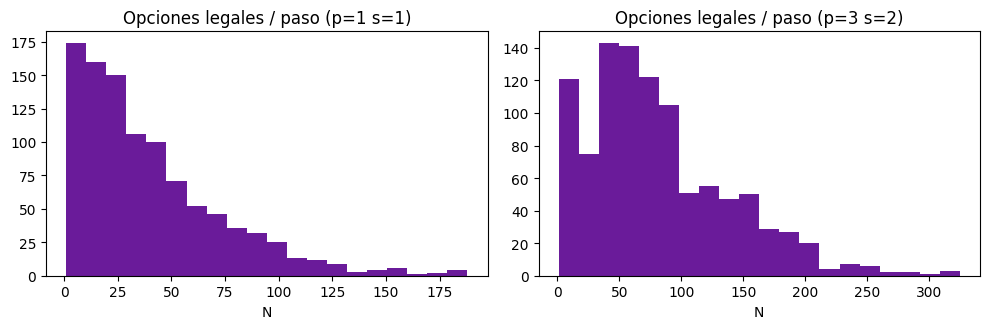

In [5]:
sample = load_transitions(transitions_path("train", 1, 1))
tr0 = sample["transitions"][0]
print("feature_version", sample["feature_version"], "dim", sample["feature_dim"])
print("names == FEATURE_NAMES", sample["feature_names"] == list(FEATURE_NAMES))
print("paso 0: n_options", tr0["n_options"], "label", tr0["label"], "feat0", len(tr0["features"][0]))
assert sample["feature_names"] == list(FEATURE_NAMES)
assert 0 <= tr0["label"] < tr0["n_options"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, (p, s) in zip(axes, REGIMES):
    data = load_transitions(transitions_path("train", p, s))
    ax.hist([t["n_options"] for t in data["transitions"]], bins=20, color="#6a1b9a")
    ax.set_title(f"Opciones legales / paso (p={p} s={s})")
    ax.set_xlabel("N")
fig.tight_layout()
plt.show()

## Comparación puntual de maestros (1 pedido, p=3 s=2)

`receding_horizon_ep` packea el resto con privilegio y proyecta. Puede diferir del de máximo volumen.

In [6]:
oid = ids["train"][0]
problem = order_to_problem(datasets["train"], oid, lookahead_p=3, select_s=2)
tr_vol, st_vol = collect_order_transitions(problem, lookahead_p=3, select_s=2, teacher="privileged_volume_ep")
tr_rh, st_rh = collect_order_transitions(problem, lookahead_p=3, select_s=2, teacher="receding_horizon_ep")
n_cmp = min(len(tr_vol), len(tr_rh))
n_diff = sum(a["label"] != b["label"] for a, b in zip(tr_vol[:n_cmp], tr_rh[:n_cmp]))
print("pedido", oid)
print("pasos volume / receding:", len(tr_vol), len(tr_rh))
print("etiquetas distintas:", n_diff, f"({100 * n_diff / max(n_cmp, 1):.1f}%)")
print("packed volume / receding:", st_vol["n_packed"], st_rh["n_packed"])
print("segundos:", round(st_vol["seconds"], 2), round(st_rh["seconds"], 2))

pedido 00100463
pasos volume / receding: 48 48
etiquetas distintas: 43 (89.6%)
packed volume / receding: 48 48
segundos: 4.69 43.55


In [7]:
out = REPORTS_DIR / "02_transitions.json"
payload = {
    "fase": 2,
    "teacher": TEACHER_NAME,
    "seed": SEED,
    "feature_version": FEATURE_VERSION,
    "feature_dim": FEATURE_DIM,
    "table": reports,
    "holdout_producto_excluded": holdout_ids,
}
out.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
print("reporte", out)

reporte /home/edmundo/packing-services/online_policy_ml/artifacts/reports/02_transitions.json


Siguiente: `03_imitacion.ipynb`.